In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)

In [9]:
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()
# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# pytorch 텐서로 변환
x_train_t = torch.tensor(x_train,dtype=torch.float32)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [10]:
# 분류모델 정의
class BinaryClassifier(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.fc1 = nn.Linear( 2 , 16)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(16 ,1 )    
  def forward(self, x):    
    x = self.relu( self.fc1(x) )    
    output = self.fc2(x) 
    return output
model = BinaryClassifier()    
model

BinaryClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01,momentum=0)
x_train_dataset = TensorDataset(x_train_t, y_train_t)
x_train_loader = DataLoader(x_train_dataset,batch_size=1,shuffle=True)

In [12]:
# 훈련루프
from tqdm import tqdm
epochs = 100
train_losses , train_accs = [], []
for epoch in tqdm(range(epochs)):
  total_loss, total_acc = 0.0 , 0.0
  for x,y in x_train_loader:
    # 가중치 초기화
    optimizer.zero_grad()
    # forward
    predict = model(x).squeeze(1)
    # loss 구하고        
    loss = criterion(predict,y)
    # backward
    loss.backward()
    # 가중치 업데이트
    optimizer.step()

    total_loss += loss.item()    
    
    predict = 1 if torch.sigmoid(predict)>=0.5 else 0
    total_acc += int(predict == int(y.item()))
  train_losses.append( total_loss / len(x_train_loader) )
  train_accs.append( total_acc / len(x_train_loader) )


100%|██████████| 100/100 [00:12<00:00,  7.81it/s]


Text(0.5, 1.0, '0.959375')

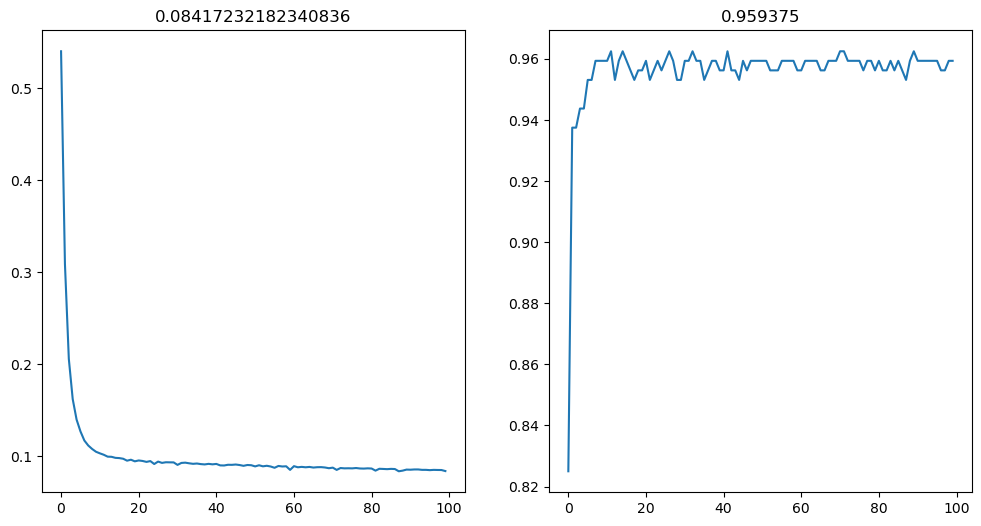

In [13]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(range(epochs),train_losses)
ax[0].set_title(train_losses[-1])
ax[1].plot(range(epochs),train_accs)
ax[1].set_title(train_accs[-1])

In [14]:
# 평가
with torch.no_grad():
  predict = model(x_test_t).squeeze(1)  
  loss = criterion(predict, y_test_t)

  predict = (torch.sigmoid(predict) >= 0.5).float()
  print(f'{loss:.4f}')
  print(accuracy_score(y_test_t, predict))

0.1680


RuntimeError: Numpy is not available

# 회귀

In [ ]:
# 회귀 데이터 생성
X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=5,
    n_informative=5,
    noise=20.0,
    random_state=42
)
# 데이터 정규화
scaler_X_reg = StandardScaler()
X_reg = scaler_X_reg.fit_transform(X_reg)

scaler_y_reg = StandardScaler()
y_reg = scaler_y_reg.fit_transform(y_reg.reshape(-1, 1)).flatten()

# 학습/테스트 분할 (80/20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# PyTorch 텐서로 변환
X_reg_train_tensor = torch.FloatTensor(X_reg_train)
y_reg_train_tensor = torch.FloatTensor(y_reg_train).reshape(-1, 1)
X_reg_test_tensor = torch.FloatTensor(X_reg_test)
y_reg_test_tensor = torch.FloatTensor(y_reg_test).reshape(-1, 1)

print(f"회귀 데이터셋 생성 완료")
print(f"훈련 데이터: {X_reg_train_tensor.shape}")
print(f"테스트 데이터: {X_reg_test_tensor.shape}")
print(f"목표값 범위: [{y_reg.min():.4f}, {y_reg.max():.4f}]")

# 모델정의

In [ ]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 16)
        self.fc2 = nn.Linear(16, 1)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))  
        output = self.fc2(x)
        return output
model_reg =  RegressionModel()   

# SGD 설정 및 훈련

In [ ]:
# SGD 최적화기 설정 (회귀용)
criterion_reg = nn.MSELoss()  # 회귀 손실함수: MSE
optimizer_sgd_reg = optim.SGD(model_reg.parameters(), lr=0.01, momentum=0)

# DataLoader (batch_size=1 for true SGD)
reg_dataset = TensorDataset(X_reg_train_tensor, y_reg_train_tensor)
reg_loader = DataLoader(reg_dataset, batch_size=1, shuffle=True)

# 훈련 루프
num_epochs = 150
train_losses_reg = []
train_r2_scores = []

from tqdm import tqdm
for epoch in tqdm(range(num_epochs)):
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    for X_batch, y_batch in reg_loader:
        optimizer_sgd_reg.zero_grad()
        # Forward pass
        outputs = model_reg(X_batch)        
        # Backward pass + SGD 업데이트    
        loss = criterion_reg(outputs, y_batch)    
        loss.backward()
        optimizer_sgd_reg.step()

        total_loss += loss.item() * X_batch.size(0)  # torch size는 shape
        
        # R² 점수 계산을 위한 데이터 수집
        with torch.no_grad():
            all_predictions.append(outputs.item())
            all_targets.append(y_batch.item())
    
    avg_loss = total_loss / len(reg_loader)
    r2 = r2_score(all_targets, all_predictions)
    train_losses_reg.append(avg_loss)
    train_r2_scores.append(r2)
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}, R²: {r2:.4f}")

print("\n회귀 모델 훈련 완료!")

# 회귀모델 평가

In [ ]:
# 테스트 데이터에 대한 평가
with torch.no_grad():
    y_pred_reg = model_reg(X_reg_test_tensor)
    test_mse = mean_squared_error(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_r2 = r2_score(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_rmse = np.sqrt(test_mse)

print("\n[회귀 문제 결과]")
print(f"테스트 MSE: {test_mse:.4f}")
print(f"테스트 RMSE: {test_rmse:.4f}")
print(f"테스트 R²: {test_r2:.4f}")